# ME 455
Author: Conor Hayes

## Problem 2
Solve the following 2D optimization problem for the variable x = [x1, x2]:
```
[see assignment pdf]
```

using gradient descent with Armijo line search. The line search process in each iteration is
summarized in the pseudocode below. Note that, in practice, the parameter ↵ should be small
(between 10^-4 to 10^-2) and the parameter $\beta$ should be between 0.2 to 0.8. Use the initial
guess of the variable x = [-4, -2], use the following parameters $\gamma_0 = 1$, $\alpha = 10^{-4}$, $\beta = 0.5$,
run for 100 iterations in total.

Turn in: A plot showing the trajectory of the iterations over the contour of the objective
function, see the example ﬁgure above.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    x1, x2 = x
    return 0.26 * (x1**2 + x2**2) - 0.46 * x1 * x2

def grad_f(x):
    x1, x2 = x
    return np.array([0.52 * x1 - 0.46 * x2, 0.52 * x2 - 0.46 * x1])

def armijo_line_search(x, grad, gamma0, alpha, beta):
    gamma = gamma0
    z = -grad
    while f(x + gamma * z) > f(x) + alpha * gamma * grad @ z:
        gamma *= beta
    return gamma

# gradient descent with Armijo line search
gamma0, alpha, beta = 1.0, 1e-4, 0.5
n_iters = 100

x = np.array([-4.0, -2.0])
trajectory = [x.copy()]
for k in range(n_iters):
    grad = grad_f(x)
    gamma = armijo_line_search(x, grad, gamma0, alpha, beta)
    x = x - gamma * grad
    trajectory.append(x.copy())

trajectory = np.array(trajectory)

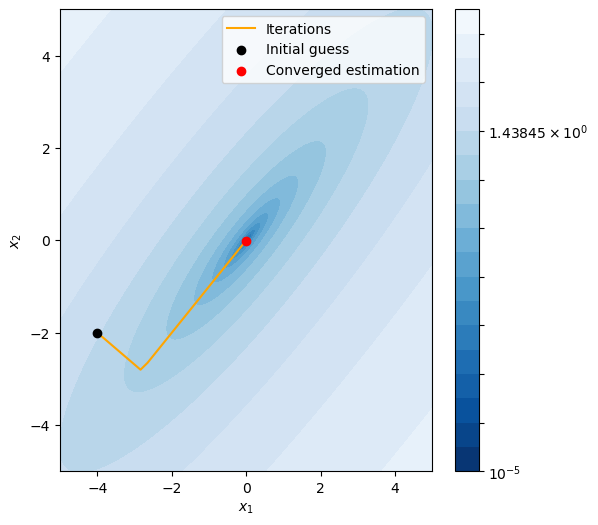

In [3]:
x1_grid = np.linspace(-5, 5, 200)
x2_grid = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = 0.26 * (X1**2 + X2**2) - 0.46 * X1 * X2

fig, ax = plt.subplots(figsize=(6, 6))
levels = np.logspace(-5, 2, 20)
cs = ax.contourf(X1, X2, np.abs(Z) + 1e-10, levels=levels, norm=plt.matplotlib.colors.LogNorm(),
                  cmap='Blues_r')
fig.colorbar(cs, ax=ax)

ax.plot(trajectory[:, 0], trajectory[:, 1], color='orange', label='Iterations')
ax.scatter(trajectory[0, 0], trajectory[0, 1], color='black', zorder=5, label='Initial guess')
ax.scatter(trajectory[-1, 0], trajectory[-1, 1], color='red', zorder=5, label='Converged estimation')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.show()

# Problem 3